In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import geopandas as gpd
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Load the data
dec23pub = pd.read_csv("https://www2.census.gov/programs-surveys/cps/datasets/2022/supp/dec22pub.csv")

# Clean the data directly
state_fips = {
    1: 'Alabama', 2: 'Alaska', 4: 'Arizona', 5: 'Arkansas', 6: 'California',
    8: 'Colorado', 9: 'Connecticut', 10: 'Delaware', 11: 'District of Columbia',
    12: 'Florida', 13: 'Georgia', 15: 'Hawaii', 16: 'Idaho', 17: 'Illinois',
    18: 'Indiana', 19: 'Iowa', 20: 'Kansas', 21: 'Kentucky', 22: 'Louisiana',
    23: 'Maine', 24: 'Maryland', 25: 'Massachusetts', 26: 'Michigan',
    27: 'Minnesota', 28: 'Mississippi', 29: 'Missouri', 30: 'Montana',
    31: 'Nebraska', 32: 'Nevada', 33: 'New Hampshire', 34: 'New Jersey',
    35: 'New Mexico', 36: 'New York', 37: 'North Carolina', 38: 'North Dakota',
    39: 'Ohio', 40: 'Oklahoma', 41: 'Oregon', 42: 'Pennsylvania',
    44: 'Rhode Island', 45: 'South Carolina', 46: 'South Dakota',
    47: 'Tennessee', 48: 'Texas', 49: 'Utah', 50: 'Vermont', 51: 'Virginia',
    53: 'Washington', 54: 'West Virginia', 55: 'Wisconsin', 56: 'Wyoming'
}

columns_to_keep = {
    # Identifiers
    'HRHHID': 'household_id',
    'HRHHID2': 'household_id_2',
    
    # Demographic characteristics
    'PRTAGE': 'age',
    'PESEX': 'sex',
    'PEEDUCA': 'education',
    'PTDTRACE': 'race',
    'PEHSPNON': 'hispanic',
    'HEFAMINC': 'family_income',
    'HRNUMHOU': 'household_size',
    'HETENURE': 'housing_tenure',
        
    # Geography
    'GESTFIPS': 'state_fips',
    'GEREG': 'region',
    'GTMETSTA': 'metro_status',
        
    # Food Security Status
    'HRFS12M1': 'food_security_status',
    'HRFS12MC': 'child_food_security',
    'HRFS12M8': 'adult_food_security',        
    # Food Spending
    'HETS8O': 'weekly_food_spending',
    'HETS8OU': 'usual_weekly_food_spending',
    
    # Program Participation  
    'HESP1': 'received_snap',
    'HESP6': 'received_school_lunch',
    'HESP7': 'received_school_breakfast',
    'HESP8': 'received_wic',
        
    # Weights
    'PWSUPWGT': 'person_supplement_weight',
    'HHSUPWGT': 'household_supplement_weight'
}

df_clean = dec23pub[columns_to_keep.keys()].copy()
df_clean = df_clean.rename(columns=columns_to_keep)

value_labels = {
    'food_security_status': {1: 'Food Secure', 2: 'Low Food Security', 3: 'Very Low Food Security'},
    'sex': {1: 'Male', 2: 'Female'},
    'hispanic': {1: 'Hispanic', 2: 'Non-Hispanic'},
    'housing_tenure': {1: 'Owned/Being Bought', 2: 'Rented', 3: 'Occupied without payment'},
    'region': {1: 'Northeast', 2: 'Midwest', 3: 'South', 4: 'West'},
    'metro_status': {1: 'Metropolitan', 2: 'Non-metropolitan', 3: 'Not Identified'},
    'family_income': {
        1: 'Less than $5,000', 2: '$5,000 to $7,499', 3: '$7,500 to $9,999',
        4: '$10,000 to $12,499', 5: '$12,500 to $14,999', 6: '$15,000 to $19,999',
        7: '$20,000 to $24,999', 8: '$25,000 to $29,999', 9: '$30,000 to $34,999',
        10: '$35,000 to $39,999', 11: '$40,000 to $49,999', 12: '$50,000 to $59,999',
        13: '$60,000 to $74,999', 14: '$75,000 to $99,999', 15: '$100,000 to $149,999',
        16: '$150,000 or more'
    },
    'received_snap': {1: 'Yes', 2: 'No'},
    'received_school_lunch': {1: 'Yes', 2: 'No'},
    'received_school_breakfast': {1: 'Yes', 2: 'No'},
    'received_wic': {1: 'Yes', 2: 'No'},
    'education': {
        -1: 'Not_relevant', -2: 'Dont_know', -3: 'Refused_to_answer', -9: 'No_response',
        31: 'Less_than_1st_grade', 32: '1st-4th_grade', 33: '5th-6th_grade', 34: '7th-8th_grade',
        35: '9th_grade', 36: '10th_grade', 37: '11th_grade', 38: '12th_grade,_no_diploma',
        39: 'High_school_graduate_diploma_or_GED', 40: 'Some_college_no_degree',
        41: 'Associate_degree_occupational_vocational', 42: 'Associate_degree_academic_program',
        43: "Bachelors_degree", 44: "Masters_degree", 45: 'Professional_school_degree_MD_DDS_DVM_etc',
        46: 'Doctorate_degree_PhD_EdD'
    }
}

In [2]:
# Apply value labels
for col, val_map in value_labels.items():
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].map(val_map).fillna(df_clean[col])

# Convert weights
weight_cols = ['person_supplement_weight', 'household_supplement_weight']
for col in weight_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col] / 10000

df_clean['state'] = df_clean['state_fips'].map(state_fips)

# Add poverty indicator based on income and program participation
poverty_income_levels = ['Less than $5,000', '$5,000 to $7,499', ...]  # Same levels as before
df_clean['poverty_indicator'] = df_clean['family_income'].apply(lambda x: 1 if x in poverty_income_levels else 0)

# Add to poverty indicator if received benefits
program_columns = ['received_snap', 'received_school_lunch', 'received_school_breakfast', 'received_wic']
for col in program_columns:
    df_clean['poverty_indicator'] = df_clean.apply(lambda row: 1 if row[col] == 'Yes' else row['poverty_indicator'], axis=1)

# Create combined food security visualization
df_analysis = df_clean.copy()
df_analysis = df_analysis[
    (df_analysis['food_security_status'].isin(['Food Secure', 'Low Food Security', 'Very Low Food Security'])) &
    (df_analysis['family_income'] != -1)
]
df_analysis['age_category'] = np.where(df_analysis['age'] < 18, 'Child (0-17)', 'Adult (18+)')

# Calculate rates
results = []
income_mapping = {
    'Less than $5,000': '0-5K',
    '$5,000 to $7,499': '5-7.5K',
    '$7,500 to $9,999': '7.5-10K',
    '$10,000 to $12,499': '10-12.5K',
    '$12,500 to $14,999': '12.5-15K',
    '$15,000 to $19,999': '15-20K',
    '$20,000 to $24,999': '20-25K',
    '$25,000 to $29,999': '25-30K',
    '$30,000 to $34,999': '30-35K',
    '$35,000 to $39,999': '35-40K',
    '$40,000 to $49,999': '40-50K',
    '$50,000 to $59,999': '50-60K',
    '$60,000 to $74,999': '60-75K',
    '$75,000 to $99,999': '75-100K',
    '$100,000 to $149,999': '100-150K',
    '$150,000 or more': '150K+'
}

income_order = [
    '0-5K', '5-7.5K', '7.5-10K', '10-12.5K', '12.5-15K', 
    '15-20K', '20-25K', '25-30K', '30-35K', '35-40K',
    '40-50K', '50-60K', '60-75K', '75-100K', '100-150K', '150K+'
]

for income in df_analysis['family_income'].unique():
    income_group = df_analysis[df_analysis['family_income'] == income]
    child_group = income_group[income_group['age_category'] == 'Child (0-17)']
    child_insecure = (child_group['food_security_status'].isin(['Low Food Security', 'Very Low Food Security']) *
                      child_group['person_supplement_weight']).sum() / child_group['person_supplement_weight'].sum() * 100 if len(child_group) > 0 else 0
    adult_group = income_group[income_group['age_category'] == 'Adult (18+)']
    adult_insecure = (adult_group['food_security_status'].isin(['Low Food Security', 'Very Low Food Security']) *
                      adult_group['person_supplement_weight']).sum() / adult_group['person_supplement_weight'].sum() * 100 if len(adult_group) > 0 else 0
    results.append({
        'family_income': income_mapping.get(income, income),
        'Child Food Insecurity': child_insecure,
        'Adult Food Insecurity': adult_insecure,
        'sample_size': len(income_group)
    })

results_df = pd.DataFrame(results)
results_df['income_order'] = pd.Categorical(
    results_df['family_income'], categories=income_order, ordered=True
)
results_df = results_df.sort_values('income_order')

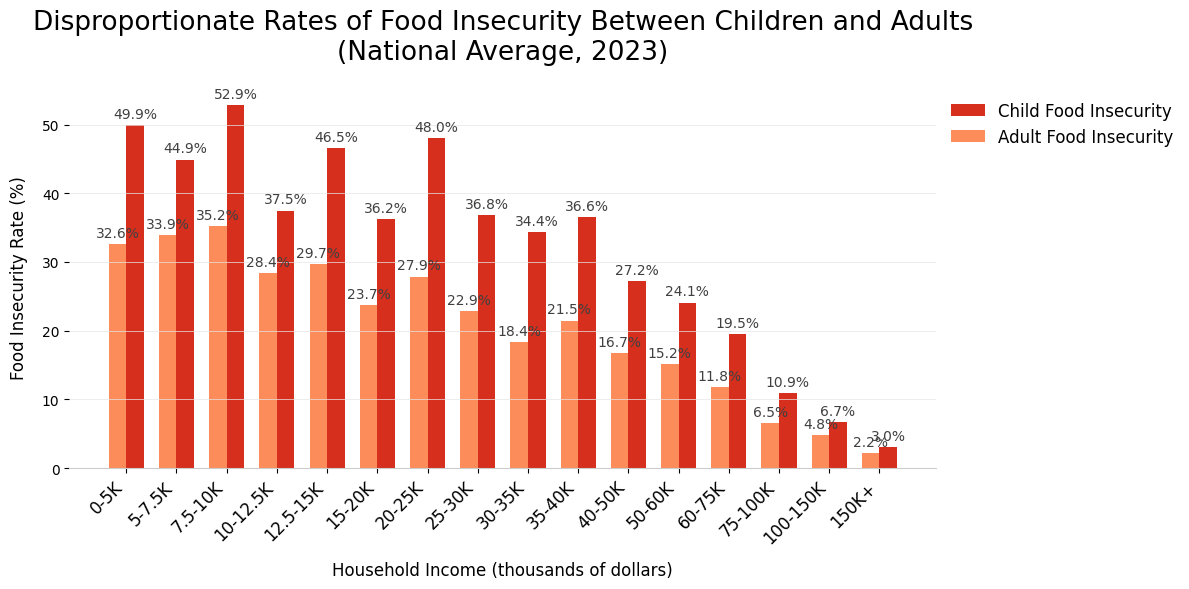

In [4]:
# Define a color palette matching the map (OrRd color palette from seaborn)
color_palette = sns.color_palette("OrRd", n_colors=3)

# Set up the figure
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot the side-by-side bar chart
bar_width = 0.35  # Width of the bars
index = np.arange(len(results_df))  # The x locations for the groups

bar1 = ax1.bar(index, results_df['Adult Food Insecurity'], bar_width, label='Adult Food Insecurity', color=color_palette[1])
bar2 = ax1.bar(index + bar_width, results_df['Child Food Insecurity'], bar_width, label='Child Food Insecurity', color=color_palette[2])

# Customize the plot
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax1.spines['bottom'].set_color('#CCCCCC')
ax1.yaxis.grid(True, color='#E6E6E6', linestyle='-', linewidth=0.5)
ax1.xaxis.grid(False)

# Labeling
ax1.set_xticks(index + bar_width / 2)
ax1.set_xticklabels(results_df['family_income'], rotation=45, ha='right', fontsize=12)
ax1.set_xlabel('Household Income (thousands of dollars)', fontsize=12, labelpad=10)
ax1.set_ylabel('Food Insecurity Rate (%)', fontsize=12, labelpad=10)
ax1.set_title('Disproportionate Rates of Food Insecurity Between Children and Adults\n(National Average, 2023)', fontsize=19, pad=20)

# Move legend into the plot area
handles, labels = ax1.get_legend_handles_labels() 
ax1.legend(handles[::-1], labels[::-1], title=None, bbox_to_anchor=(1, 1), loc='upper left', frameon=False, fontsize=12)

# Add percentage labels
for bar in [bar1, bar2]:
    ax1.bar_label(bar, fmt='%.1f%%', fontsize=10, padding=3, color='#404040')

plt.tight_layout()
plt.show()

C:\Users\shaya\AppData\Local\Temp\ipykernel_45028\3576277252.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


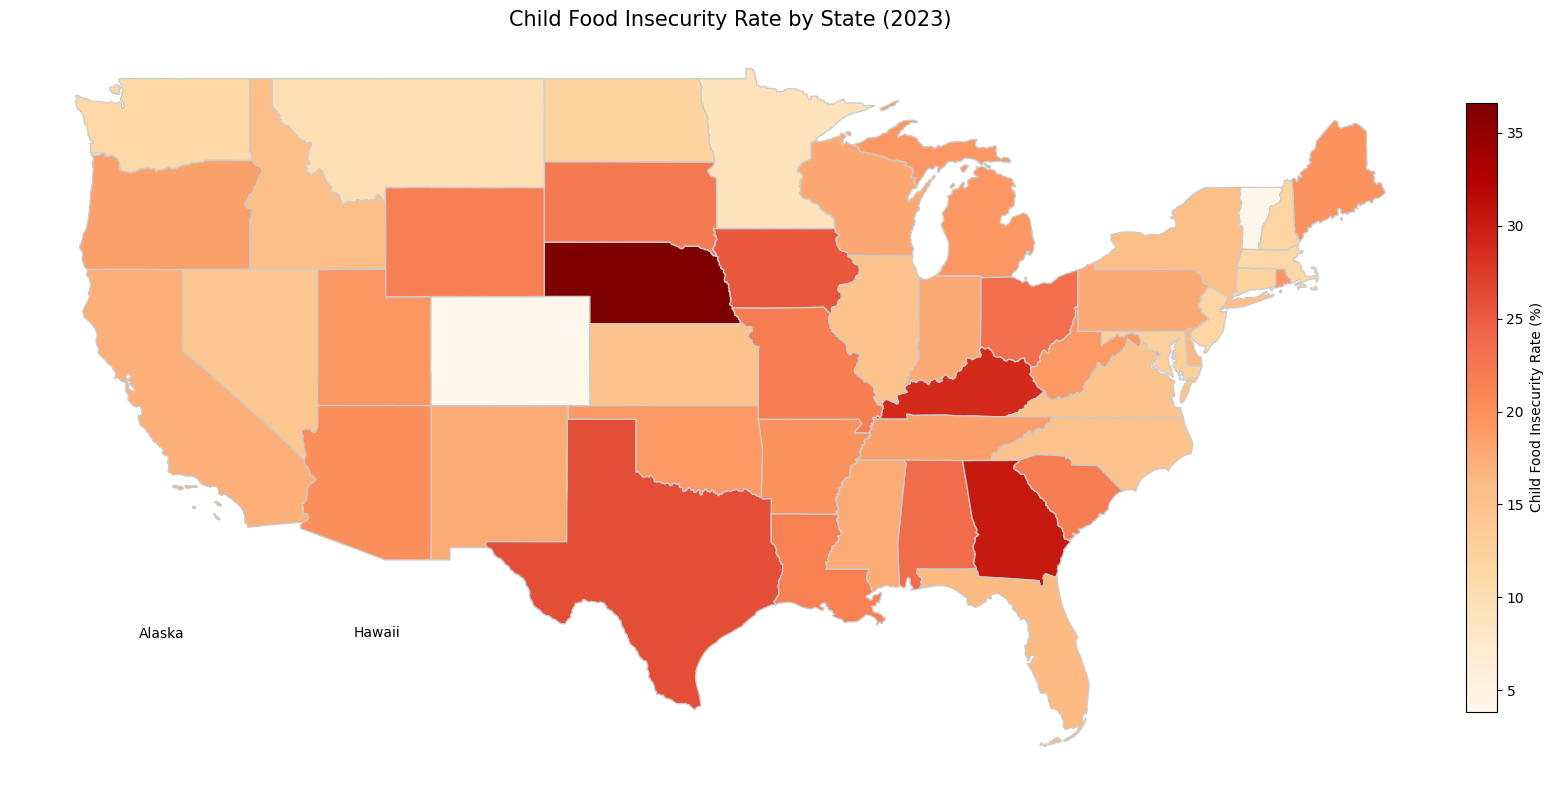

In [5]:
# Create the map visualization for child food insecurity and poverty rate
# Calculate state-level rates for child food insecurity and poverty
state_results = []
for state in df_clean['state'].unique():
    state_group = df_clean[df_clean['state'] == state]
    child_group = state_group[state_group['age'] < 18]
    child_insecure = (child_group['food_security_status'].isin(['Low Food Security', 'Very Low Food Security']) *
                      child_group['person_supplement_weight']).sum() / child_group['person_supplement_weight'].sum() * 100 if len(child_group) > 0 else 0
    poverty_rate = (state_group['poverty_indicator'] == 1).sum() / len(state_group) * 100 if len(state_group) > 0 else 0
    state_results.append({
        'state': state,
        'Child Food Insecurity': child_insecure,
        'Poverty Rate': poverty_rate
    })

state_df = pd.DataFrame(state_results)

# Load and merge data with US shapefiles
us_states = gpd.read_file('https://www2.census.gov/geo/tiger/GENZ2018/shp/cb_2018_us_state_20m.zip')
us_states['state_name'] = us_states['NAME']
map_data = us_states.merge(state_df, how='left', left_on='state_name', right_on='state').dropna(subset=['geometry'])

# Color palette
color_palette = 'OrRd'

# Plot child food insecurity
fig1, ax1 = plt.subplots(figsize=(16, 8))
contiguous_us = map_data[~map_data['state_name'].isin(['Alaska', 'Hawaii'])]
contiguous_us.plot(
    column='Child Food Insecurity',
    ax=ax1,
    cmap=color_palette,
    legend=True,
    edgecolor='0.8',
    legend_kwds={'label': "Child Food Insecurity Rate (%)", 'orientation': "vertical", 'shrink': 0.9, 'fraction': 0.02, 'pad': 0.01}
)
ax1.set_title("Child Food Insecurity Rate by State (2023)", fontsize=15)
ax1.axis('off')

# Add inset maps for Alaska and Hawaii
ax1_ak = inset_axes(ax1, width="10%", height="10%", loc='lower left', bbox_to_anchor=(0.1, 0.12, 0.01, 1), bbox_transform=ax1.transAxes)
ax1_ak.set_title("Alaska", fontsize=10)
ax1_ak.axis('off')
alaska = map_data[map_data['state_name'] == 'Alaska']
alaska.plot(column='Child Food Insecurity', ax=ax1_ak, cmap=color_palette, legend=False)

ax1_hi = inset_axes(ax1, width="10%", height="10%", loc='lower right', bbox_to_anchor=(0.25, 0.12, 0.01, 1), bbox_transform=ax1.transAxes)
ax1_hi.set_title("Hawaii", fontsize=10)
ax1_hi.axis('off')
hawaii = map_data[map_data['state_name'] == 'Hawaii']
hawaii.plot(column='Child Food Insecurity', ax=ax1_hi, cmap=color_palette, legend=False)

plt.tight_layout()
plt.show()


C:\Users\shaya\AppData\Local\Temp\ipykernel_45028\1085612646.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


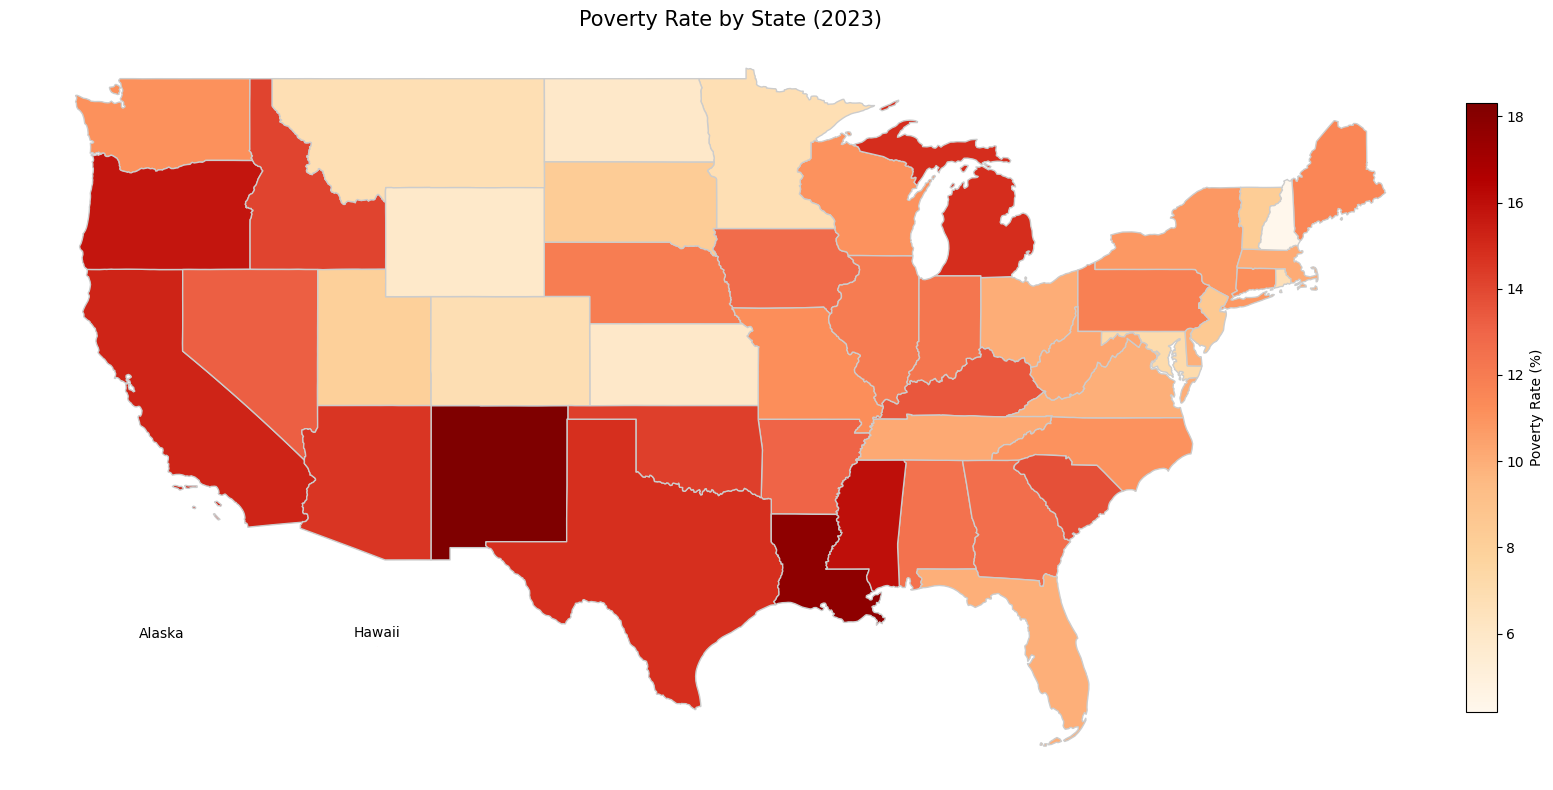

In [6]:
# Plot poverty rate
fig2, ax2 = plt.subplots(figsize=(16, 8))
contiguous_us.plot(
    column='Poverty Rate',
    ax=ax2,
    cmap=color_palette,
    legend=True,
    edgecolor='0.8',
    legend_kwds={'label': "Poverty Rate (%)", 'orientation': "vertical", 'shrink': 0.9, 'fraction': 0.02, 'pad': 0.01}
)
ax2.set_title("Poverty Rate by State (2023)", fontsize=15)
ax2.axis('off')

# Add inset maps for Alaska and Hawaii
ax2_ak = inset_axes(ax2, width="10%", height="10%", loc='lower left', bbox_to_anchor=(0.1, 0.12, 0.01, 1), bbox_transform=ax2.transAxes)
ax2_ak.set_title("Alaska", fontsize=10)
ax2_ak.axis('off')
alaska.plot(column='Poverty Rate', ax=ax2_ak, cmap=color_palette, legend=False)

ax2_hi = inset_axes(ax2, width="10%", height="10%", loc='lower right', bbox_to_anchor=(0.25, 0.12, 0.01, 1), bbox_transform=ax2.transAxes)
ax2_hi.set_title("Hawaii", fontsize=10)
ax2_hi.axis('off')
hawaii.plot(column='Poverty Rate', ax=ax2_hi, cmap=color_palette, legend=False)

plt.tight_layout()
plt.show()
